In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import argparse
from tqdm import tqdm

import src.utils.utils as utils
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
else:
    print(f"{torch.cuda.is_available()}")
    dev = "cpu"

In [18]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
Y_flat = utils.normalize(Y_flat, dim=0)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

patch_size = 15
batch_size=10
epochs=100
lr=1e-2

Y = utils.oneD_to_2d(Y_flat)
A = utils.oneD_to_2d(A_flat)
B = Y.shape[0]
H = Y.shape[-1]
Y = Y.to(torch.float32)
Y = Y.unsqueeze(0)
if H < 224:
    Y = F.interpolate(Y, size=(224,224))
else:
    H = 224
A = A.unsqueeze(0)
# Y = Y/torch.max(Y, dim=0)

with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

# model = rsfm.FoundationModel(model_name="DOFA", channels=B, patch_size=patch_size, im_size=H, n_em=c, wavelengths=wavelengths)
# model.get_adapter_size()
# F = model.get_features(Y)
# print(F.shape)

In [19]:
import sys
sys.path.append("/home/ids/edabier/HSU/DOFA")
from dofa_v1 import vit_base_patch16

n_features = 1
check_point = torch.load('/home/ids/edabier/HSU/DOFA/checkpoints/DOFA_ViT_base_e100.pth', map_location=dev)
dofa = vit_base_patch16(n_features=n_features)
dofa.load_state_dict(check_point, strict=False)
Y = Y[:,:,:224, :224]
A = A[:,:,:224, :224]

features = dofa.forward_features(Y, wavelengths)
D = int(features.shape[0]/n_features)
unmixer = rsfm.Unmixing_from_features(D=D, p=14, B=B, c=c, n_features=n_features, upsample_twice=True)

In [20]:
# class UpsampleBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, kernel_size):
#         super().__init__()
#         self.conv_transpose = nn.ConvTranspose2d(
#             in_channels,
#             out_channels,
#             kernel_size=kernel_size,
#             stride=1,
#             padding=0,
#             bias=False
#         )

#     def forward(self, x):
#         return self.conv_transpose(x)
    
# upsample = nn.Sequential(
#             UpsampleBlock(1, 1, kernel_size=45),
#             UpsampleBlock(1, 1, kernel_size=45),
#             UpsampleBlock(1, 1, kernel_size=45),
#             UpsampleBlock(1, 1, kernel_size=45),
#             UpsampleBlock(1, 1, kernel_size=35),
#         )
# print(upsample(features.reshape(D, 1, 14, 14)).shape)
# print("The unmixer model has : ", sum(p.numel() for p in upsample.parameters() if p.requires_grad)/1e6, "M params")

In [21]:
model = unmixer
model = models.init_decoder_weights(model, Y, c, is_unmixer=True, use_sivm=True)
print("The unmixer model has : ", sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6, "M params")
E_hat, A_hat, Y_hat = model(features)
# plt.plot(E_hat.detach().cpu())

The unmixer model has :  9.8906 M params


Epoch 0: loss = 0.861
Epoch 100: loss = 0.628
Epoch 200: loss = 0.587
Epoch 300: loss = 0.579
Epoch 400: loss = 0.577
Epoch 500: loss = 0.576
Epoch 600: loss = 0.575
Epoch 700: loss = 0.575
Epoch 800: loss = 0.574
Epoch 900: loss = 0.574


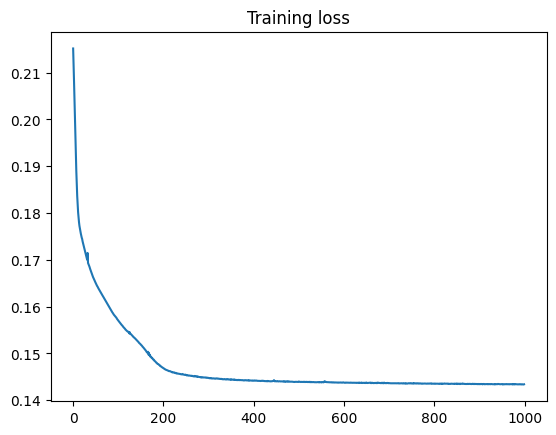

In [22]:
train_losses = []
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev)
model = unmixer

epochs, lr = 1000, 0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
for epoch in range(epochs):
    
    train_loss = 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = utils.oneD_to_2d(Y).to(dev)
        if Y.shape[-1] < 224:
            Y = F.interpolate(Y, size=(224,224))
        Y = Y[:,:,:224, :224]

        E = E.to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        if A.shape[-1] < 224:
            A = F.interpolate(A, size=(224,224))
        A = A[:,:,:224, :224]

        features = dofa.forward_features(Y, wavelengths)
        E_hat, A_hat, Y_hat = model(features)
        
        loss = model.loss(Y, Y_hat, A_hat, E_hat, W_sad=1, W_ab=0, W_tv=0, W_mse=1e-5)
        train_loss += loss.item()

        if epoch%100==0:
            print(f"Epoch {epoch}: loss =", format(loss, '.3f'))
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

    train_loss /= len(loader)
    train_losses.append(train_loss)
plt.plot(train_losses)
plt.title('Training loss')
plt.show()
# E_hat, A_hat, Y_hat = model(features)
# utils.plot_results(E_hat=E_hat, A_hat=A_hat[0], A_gt=A[0], E_gt=E)

Text(0.5, 1.0, 'Reconstructed HSI')

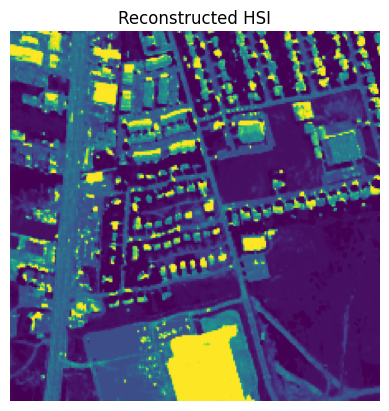

In [23]:
plt.imshow(F.interpolate(Y_hat, size=(1000,1000))[0,0].detach().cpu())
plt.axis("off")
plt.title("Reconstructed HSI")

Not taking batched E_gt
Not taking batched A_hat
Not taking batched A_gt
SAD(E, E_hat) = 0.855
MSE(A, A_hat) = 0.570


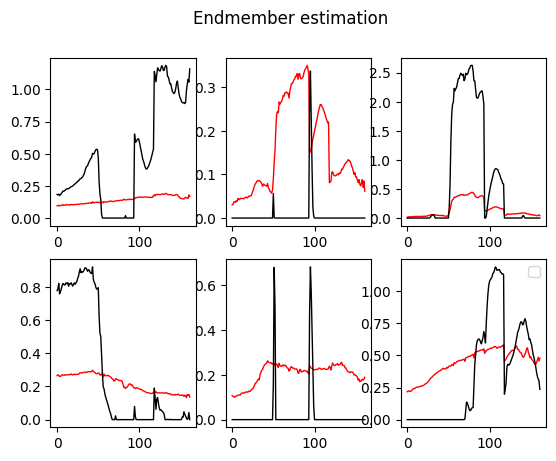

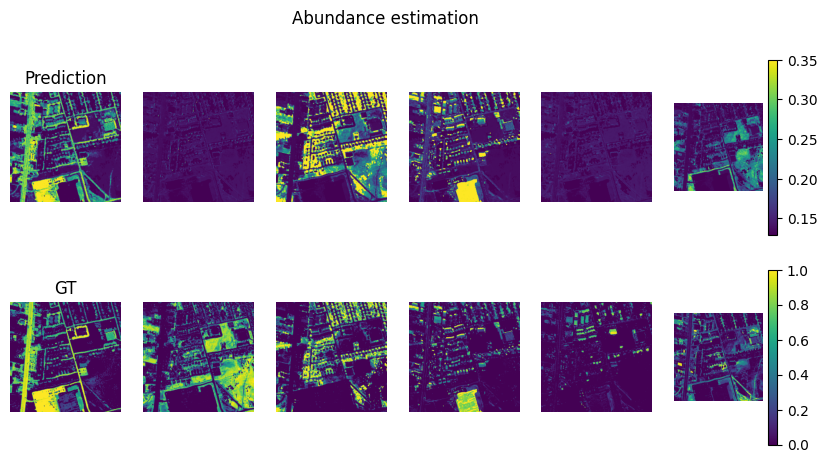

In [24]:
E_hat, A_hat, Y_hat = model(features)
utils.plot_results(E_hat, A_hat, A, E)

In [ ]:
E_hat, A_hat, Y_hat = model(Y)
# print(A_hat)

In [ ]:
loader, _, _ = utils.create_dataloader(dataset, dev=dev, batch_size=batch_size)
optimizer = optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

def criterion(Y_gt, Y_hat, E_hat, A_hat, w_ab=0.35, w_tv=0.1):
    sad = utils.SADLoss()
    loss_sad = sad(Y_gt, Y_hat)
    # print("SAD: ", loss_sad)
    loss_ab = w_ab * torch.sqrt(A_hat).mean()
    print(loss_ab)
    loss_tv = w_tv * (torch.abs(E_hat[:, 1:] - E_hat[:, :(-1)]).sum())
    # print("TV: ", loss_tv)
    # loss = loss_sad + loss_ab + loss_tv
    loss = loss_sad + loss_tv

    return loss

train_losses = []

for epoch in tqdm(range(epochs)):
    
    train_loss = 0
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = Y.to(dev)
        E = E.to(dev)
        A = A.to(dev)

        for b in range(Y.shape[0]):
            Y, _ = utils.oneD_to_2d(Y)
            A, _ = utils.oneD_to_2d(A)

            if Y[b].shape[1] > model.im_size:
                Y = Y[b, :, :model.im_size, :model.im_size]
                A = A[b, :, :model.im_size, :model.im_size]
            
            E_hat, A_hat, Y_hat = model(Y)
            # plt.imshow(A_hat[0].detach().cpu())
            # print(A_hat)
            # plt.show()
            # print(A_hat)
            loss = criterion(Y, Y_hat, E_hat, A_hat)
            train_loss += loss.item()
            
            loss.backward()
            optimizer.step()

            # with torch.no_grad():
            #     model.decoder.apply(models.weightConstraint())
    
        train_loss /= len(loader)
        train_losses.append(train_loss)
plt.plot(train_losses)
# train_losses

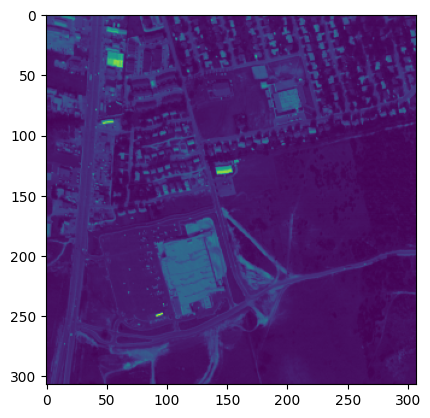

In [29]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y = torch.tensor(data["Y"])
Y = Y.to(torch.float32)
E = torch.tensor(data["E"])
B, c, N = E.shape[0], E.shape[1], Y.shape[1]

Y = Y.reshape(Y.shape[0], int(Y.shape[1]**0.5), int(Y.shape[1]**0.5))
H, W = Y.shape[1], Y.shape[2]

with open(f"/home/ids/edabier/HSU/SS-HSU_benchmark/datasets/{dataset}_wavelength", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

plt.imshow(Y.cpu()[10,:,:])

In [30]:
import sys
sys.path.append("/home/ids/edabier/HSU/DOFA")

from dofa_v1 import vit_base_patch16

state_dict = torch.load("/home/ids/edabier/HSU/DOFA/checkpoints/DOFA_ViT_base_e100.pth", map_location=dev)
dofa = vit_base_patch16()
dofa.load_state_dict(state_dict, strict=False)

_IncompatibleKeys(missing_keys=['fc_norm.weight', 'fc_norm.bias', 'head.weight', 'head.bias'], unexpected_keys=['mask_token', 'norm.weight', 'norm.bias', 'projector.weight', 'projector.bias'])

In [33]:
Y = Y[ :, :224, :224].unsqueeze(0)

features = dofa.forward_features(Y, wave_list=wavelengths)

In [4]:
GSD = 0.456
ratio = 1024 / (max(H, W))
GSD = GSD / ratio
GSD = torch.tensor([GSD])
patch_size=8

k = int(Y.shape[1]//patch_size)
s = k*patch_size
Y = Y[:, :s, :s]
_, H, W = Y.shape
# Y_norm = Y / torch.max(Y)
batched_Y = Y.unsqueeze(0)
H//patch_size

38

In [7]:
import sys
sys.path.append("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT")
import models_mae_spectral

torch.serialization.add_safe_globals([argparse.Namespace])
state_dict = torch.load("/home/ids/edabier/HSU/IEEE_TPAMI_SpectralGPT/data/SpectralGPT+.pth", map_location=dev)["model"]

img_size = 128
spectral_gpt = models_mae_spectral.mae_vit_base_patch8_128(num_frames=Y.shape[0], pred_t_dim=Y.shape[0])
# spectral_gpt = models_mae_spectral.__dict__[f"mae_vit_base_patch{patch_size}_{img_size}"]()

encoder_keys = [k for k in state_dict.keys() if k.startswith('patch_embed') or k.startswith('blocks') or k.startswith('norm')]
encoder_state_dict = {k: state_dict[k] for k in encoder_keys}
spectral_gpt.load_state_dict(encoder_state_dict, strict=False)

y_patch = Y.unsqueeze(0)[:,:,:img_size,:img_size]
# y_patch = y_patch.reshape(Y.shape[0], 1, img_size, img_size)
# print(y_patch.shape)
# y_patch = y_patch.reshape(y_patch.shape[0], y_patch[2], y_patch[1], y_patch[3])
latent, _, _ = spectral_gpt.forward_encoder(y_patch, mask_ratio=0.0)

img_size (128, 128) patch_size (8, 8) frames 162 t_patch_size 3
model initialized
torch.Size([1, 1, 162, 128, 128])
torch.Size([1, 1, 162, 128, 128])


OutOfMemoryError: CUDA out of memory. Tried to allocate 8.54 GiB. GPU 0 has a total capacity of 15.89 GiB of which 5.26 GiB is free. Including non-PyTorch memory, this process has 10.63 GiB memory in use. Of the allocated memory 10.19 GiB is allocated by PyTorch, and 150.28 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import sys
sys.path.append("/home/ids/edabier/HSU/HyperFree")
from HyperFree import build_HyperFree_vit_b, predictor

pred = build_HyperFree_vit_b(checkpoint="/home/ids/edabier/HSU/HyperFree/data/HyperFree-b.pth", image_size=batched_Y.shape[2], vit_patch_size=patch_size)
hyperfree = predictor.HyperFree_Predictor(pred)

input_y = hyperfree.transform.apply_image_torch(batched_Y)
hyperfree.set_torch_image(input_y, original_image_size=(Y.shape[1], Y.shape[2]), spectral_lengths=wavelengths, GSD=GSD)
hyperfree.features.shape

In [33]:
import src.models.foundation_models as rsfm

hyperfree_fm = rsfm.FoundationModel("HyperFree", patch_size=patch_size, im_size=H)
F = hyperfree_fm.get_features(Y=Y, wavelengths=wavelengths)